# 5. STORED PROCEDURE

## Intro : 

### Why need stored procedure?

#### Problem : 

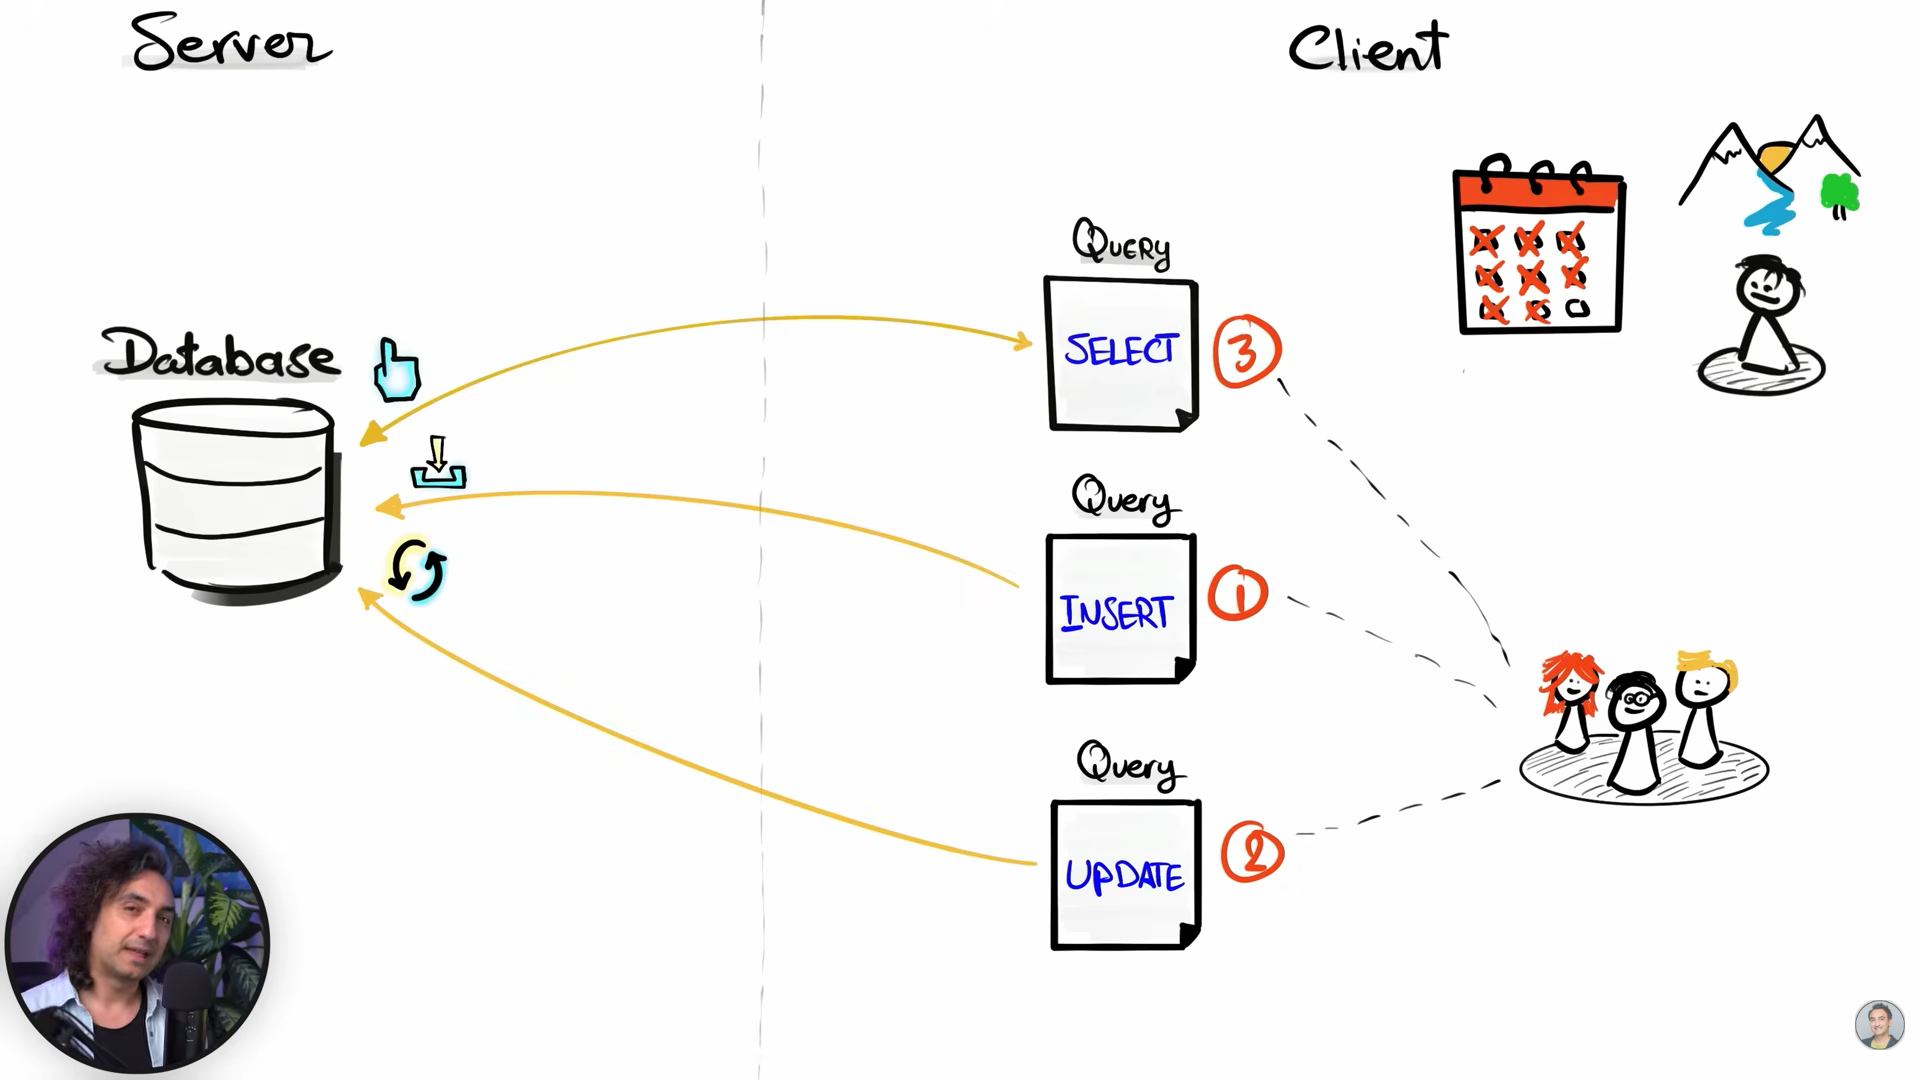

#### Solution : 

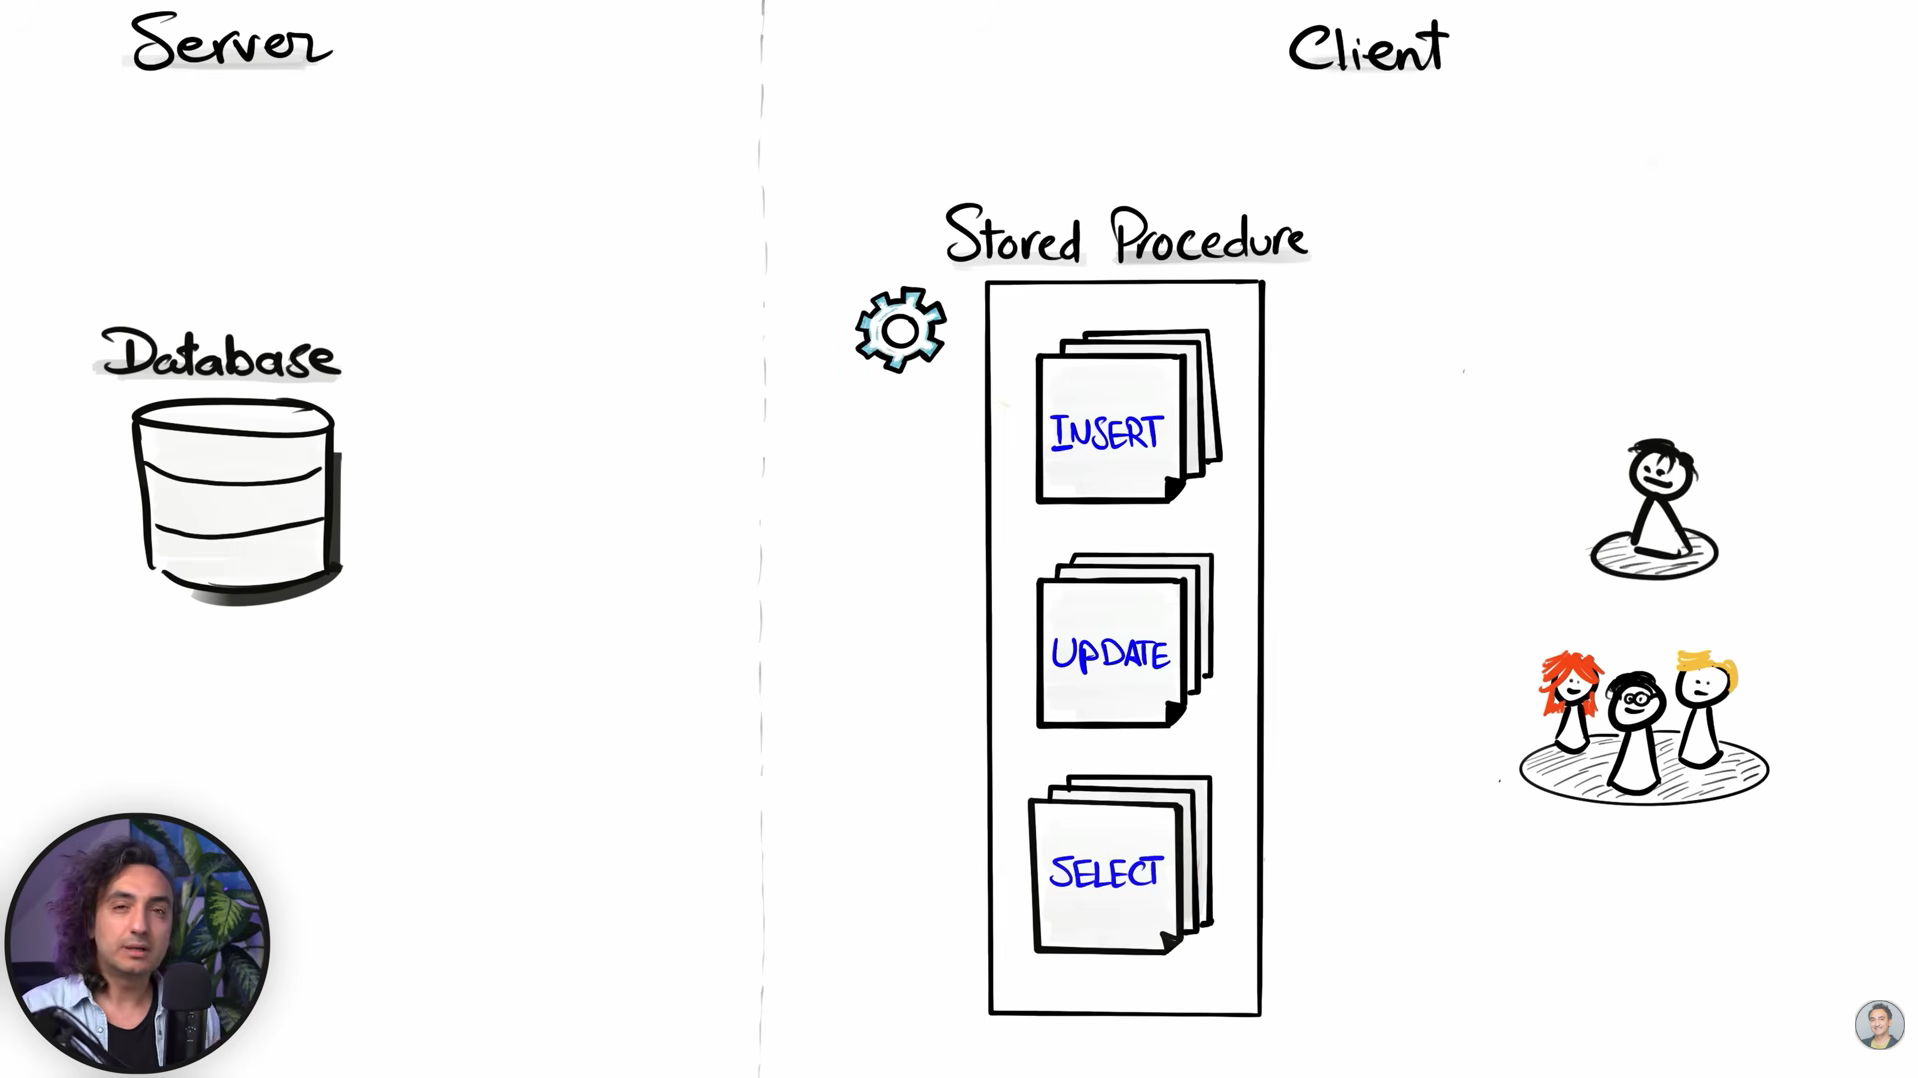

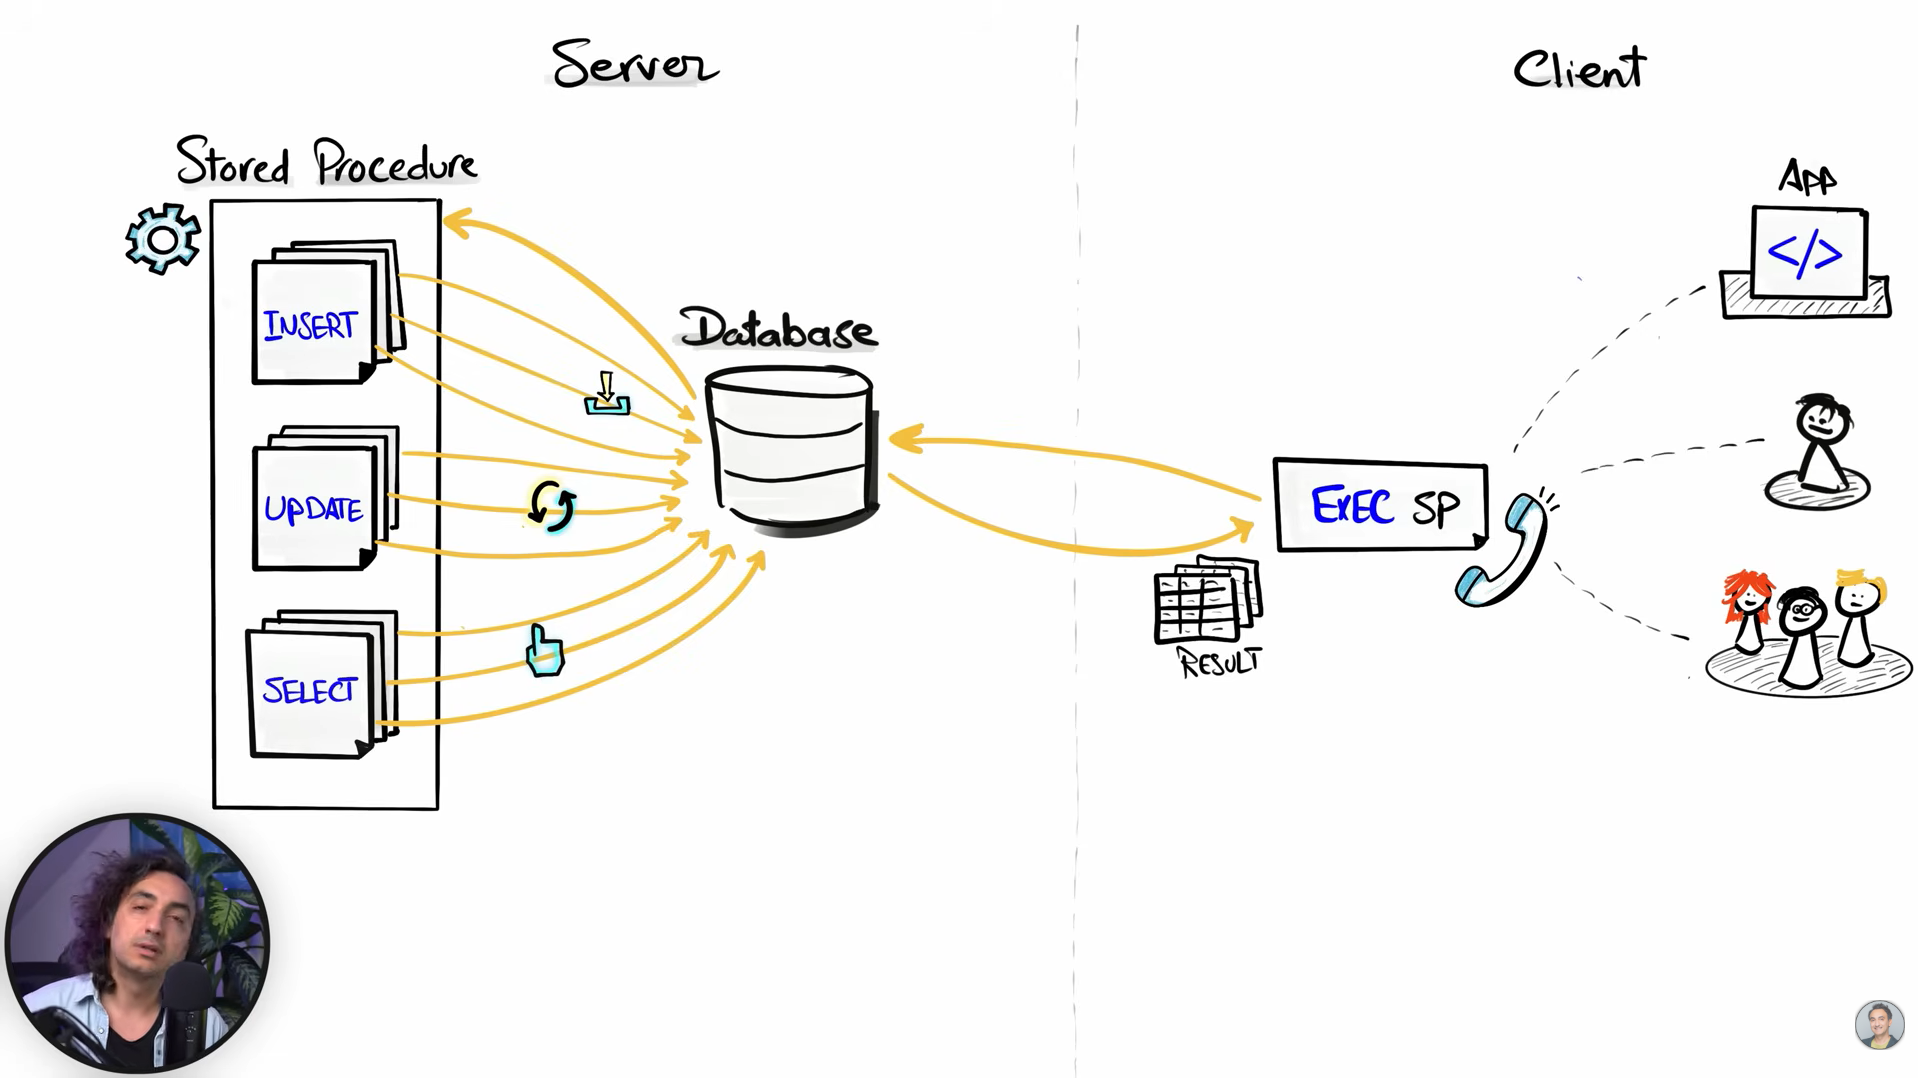

### Stored Procedure vs QUERY : 

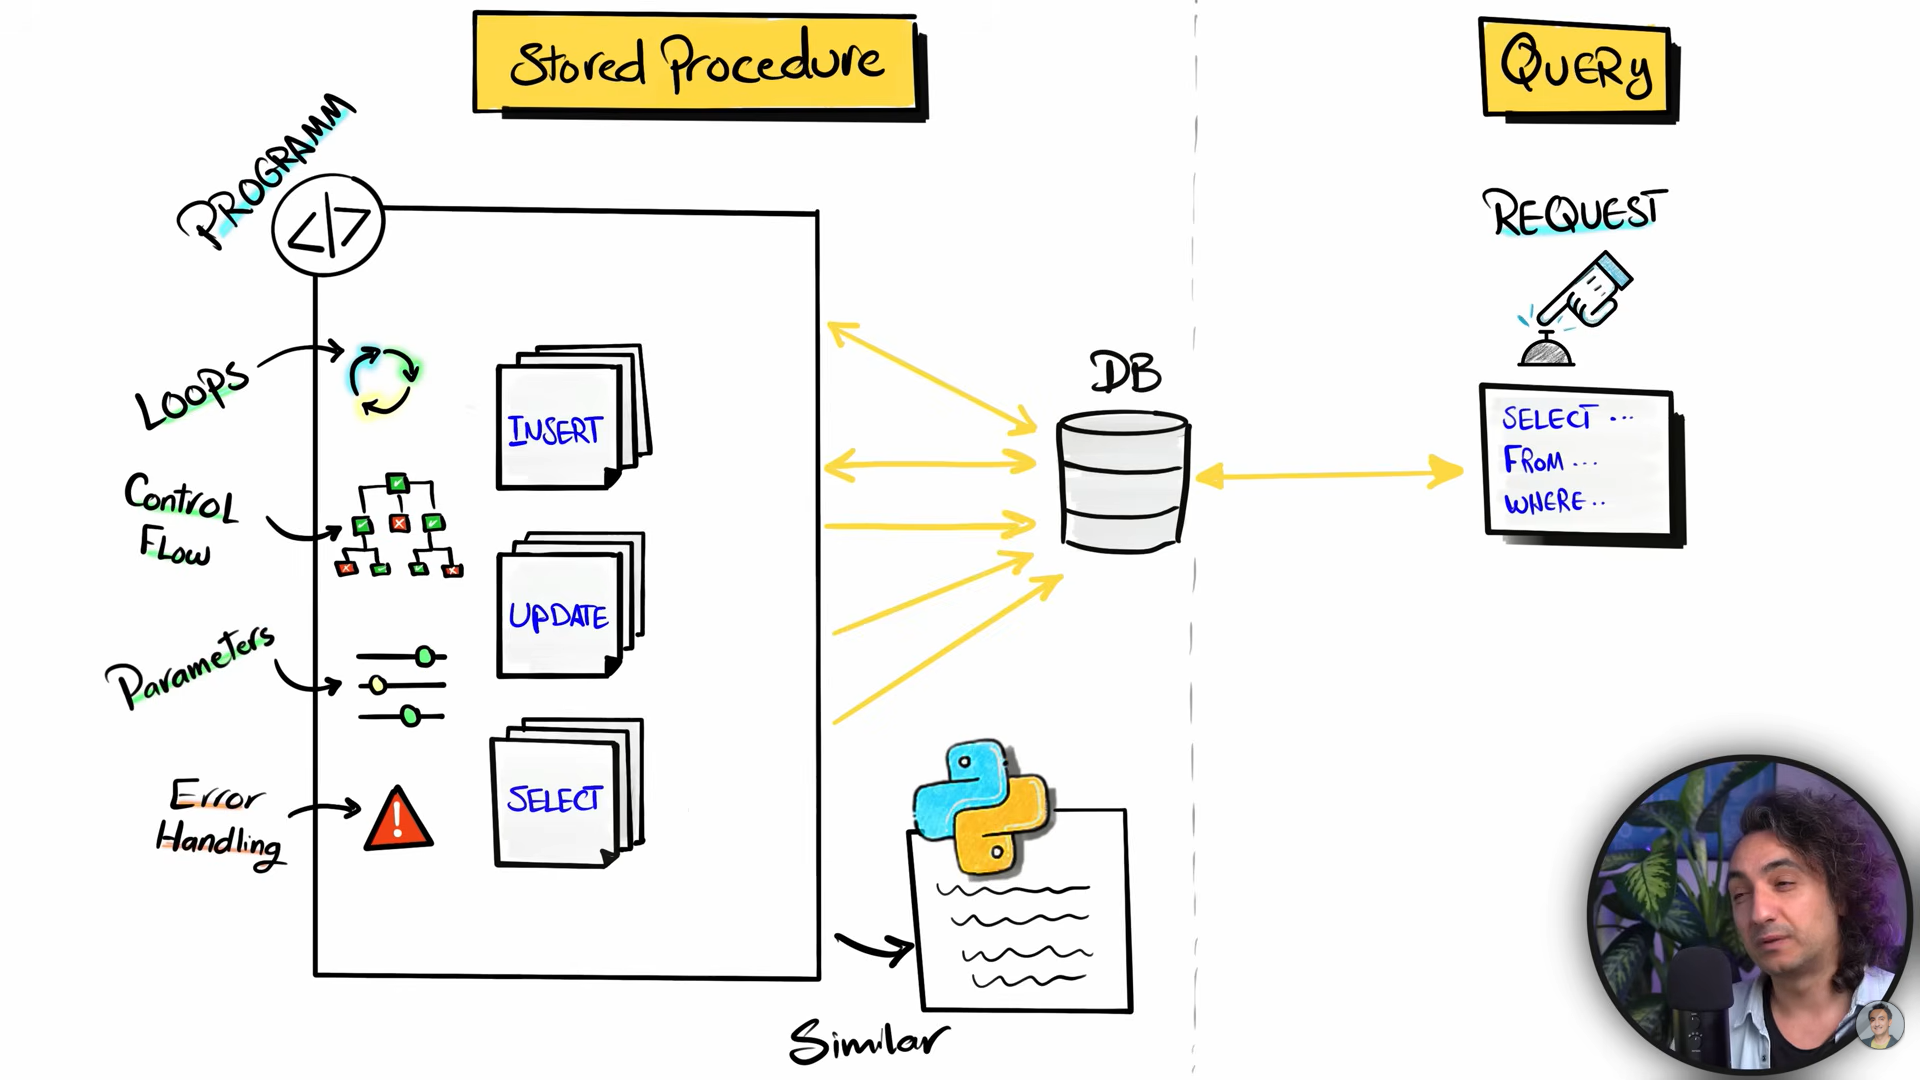

### Stored Procedure vs Coding with Python : 

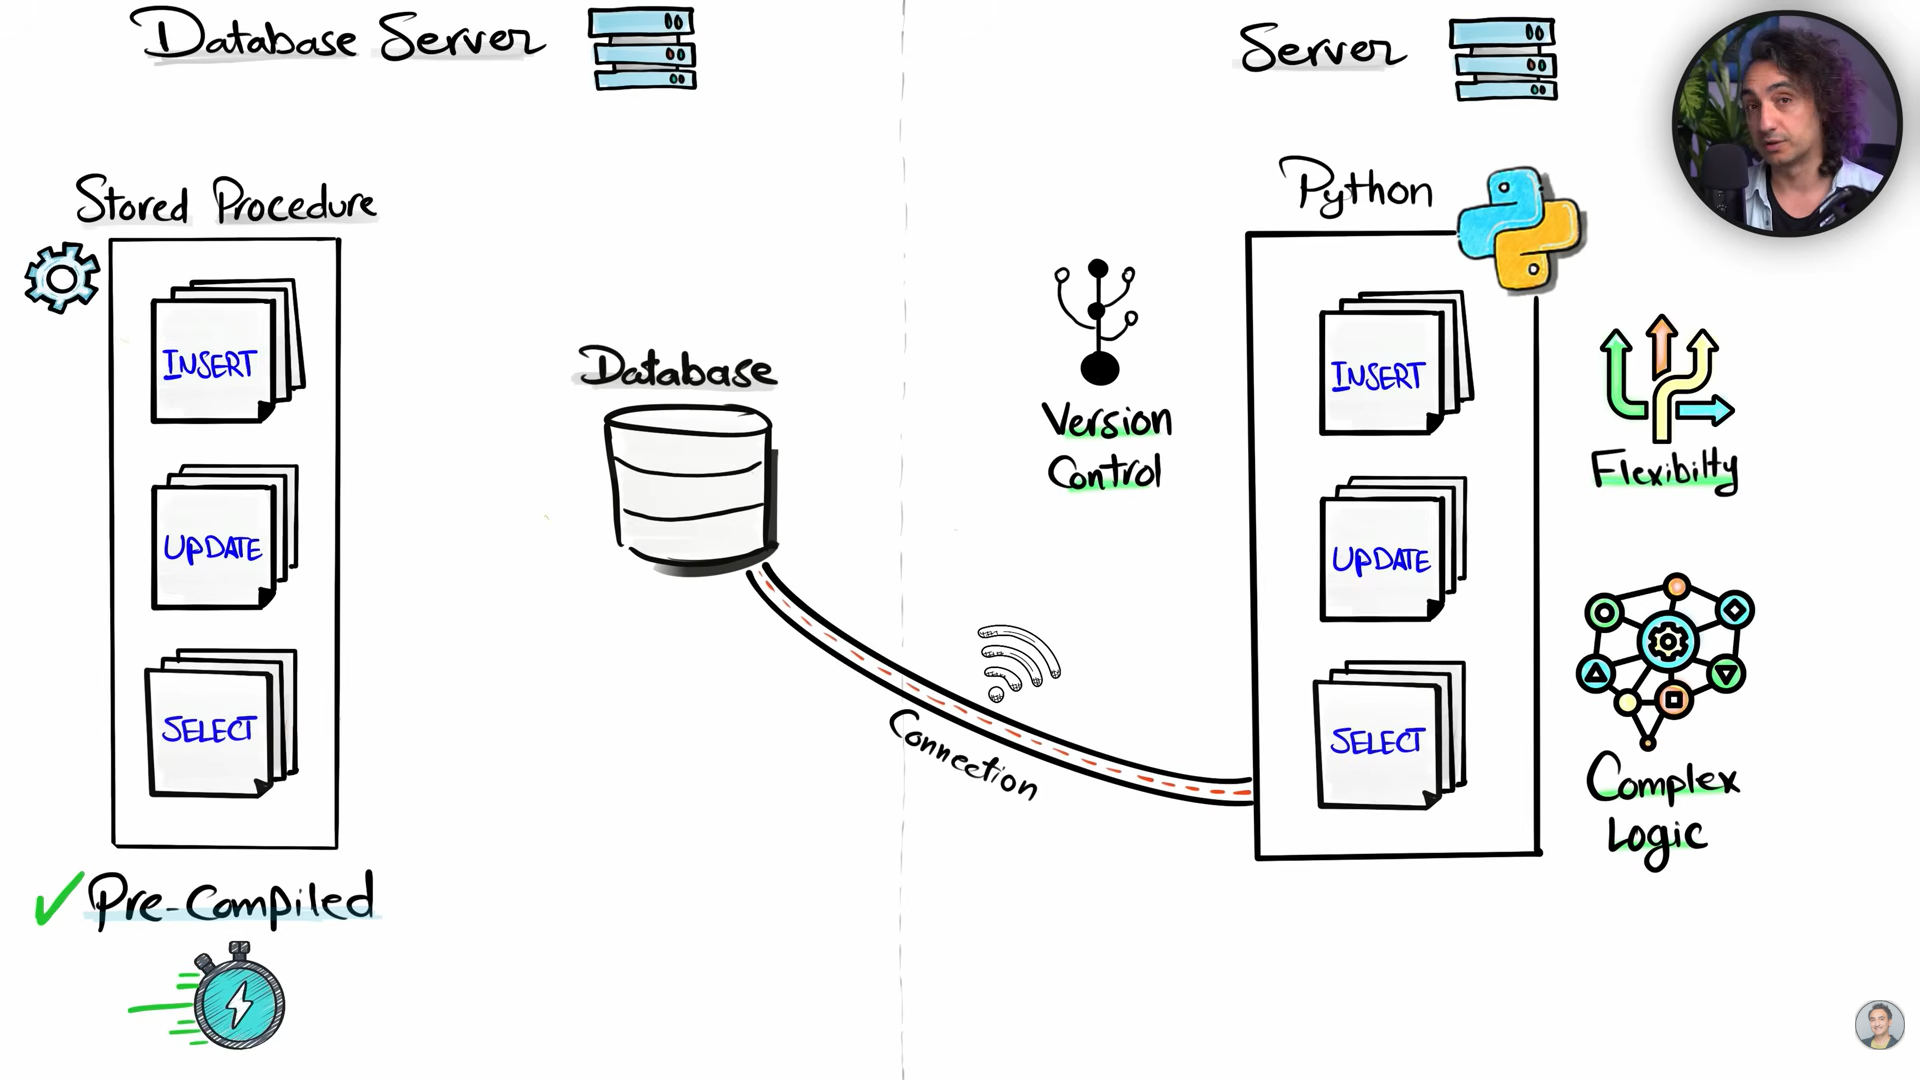

### Path in Database :

Databases --> Schema --> Programmability --> Stored Procedures -->

## Types : 

### Stored Procedure BASIC : 

#### Syntax: 

##### FOR MS SQL :

``` 
1. To Create Stored Procedure : 
CREATE PROCEDURE ProcedureName AS (
    BEGIN
        -- SQL Statements;
    END
);

2. TO Execute the Stored Procedure : 
EXEC ProcedureName;
```

##### FOR MySQL : 

``` 
1. To Create Stored Procedure : 
DELIMITER //
CREATE PROCEDURE ProcedureName()
    BEGIN
        -- SQL Statements;
    END //
DELIMITER ;


2. TO Execute the Stored Procedure : 
CALL ProcedureName;
```

#### Challenges : 

##### 1. Write a query for US customers to Find the total number of customers and the average score

In [223]:
%%sql
select 
count(customerid) as TotalCustomers,
round(AVG(COALESCE(score, 0))) as AVGScore
from customers
where country = 'USA';


Running query in 'mysql+pymysql://'

1 rows affected.

TotalCustomers,AVGScore
3,550


##### 2. Write a Stored Procedurefor query for US customers to Find the total number of customers and the average score

In [ ]:
%%sql
CREATE PROCEDURE US_Customers() 
BEGIN
select count(customerid) as TotalCustomers,
    round(avg(coalesce(score, 0))) as AVGScore
from customers
where country = 'USA';
END;


Running query in 'mysql+pymysql://'

++
||
++
++

In [232]:
%%sql
call US_Customers();

Running query in 'mysql+pymysql://'

1 rows affected.

TotalCustomers,AVGScore
3,550


### Stored Procedure PARAMETERS : 

#### What is parameters in stored procedure?

##### It is a placeholders used to pass value as input from the caller to the procedure, allowing dynamic data to be processed.

#### Syntax for PARAMETER in Stored Procedure.

##### For MS SQL : 

```
CREATE PROCEDURE ProcedureName @parameterName parameterDataType Length
AS 
BEGIN
    SELECT ....
    FROM ....
    WHERE ....;
END;
```

##### For MySQL :

```
CREATE PROCEDURE procedureName (IN/OUT/INOUT DataType)
BEGIN
    SELECT ....
    FROM ....
    WHERE ....;
END;

-- IN : Default : Passes a value into the procedure. The procedure can modify it internally, but the change is not visible outside.
-- OUT : Passes a value from the procedure back to the caller. Its initial value is NULL inside the procedure.
-- INOUT : Acts as both IN and OUT. It passes a value in, the procedure modifies it, and the final value is passed back out.
```

### Stored Procedure VARIABLES : 

#### Stored Procedure Variables : It is a placeholder used to store values to be used later in the procedure.

### Stored Procedure PARAMETERS vs Stored Procedure VARIABLES: 

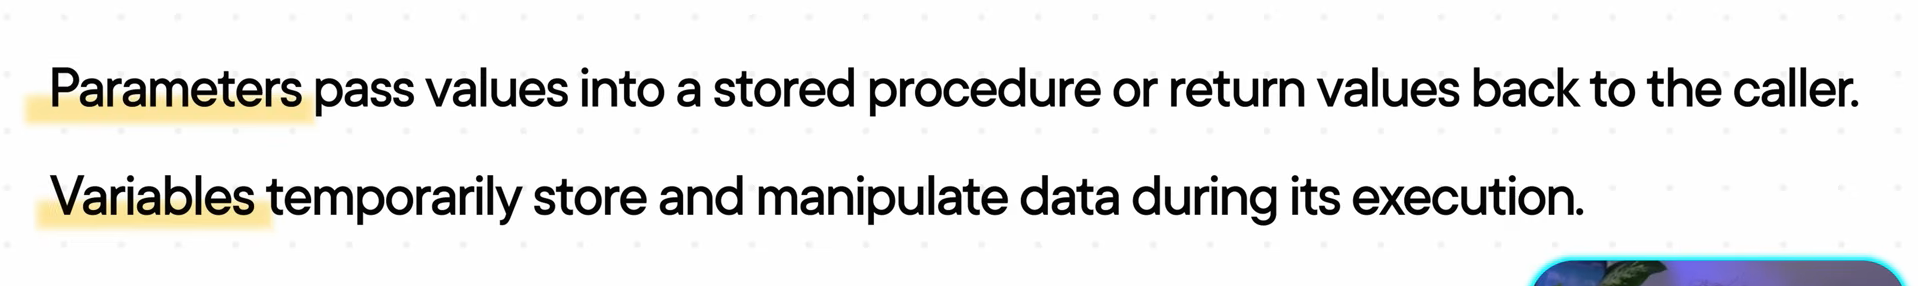

### Control Flow in Stored Procedure : 

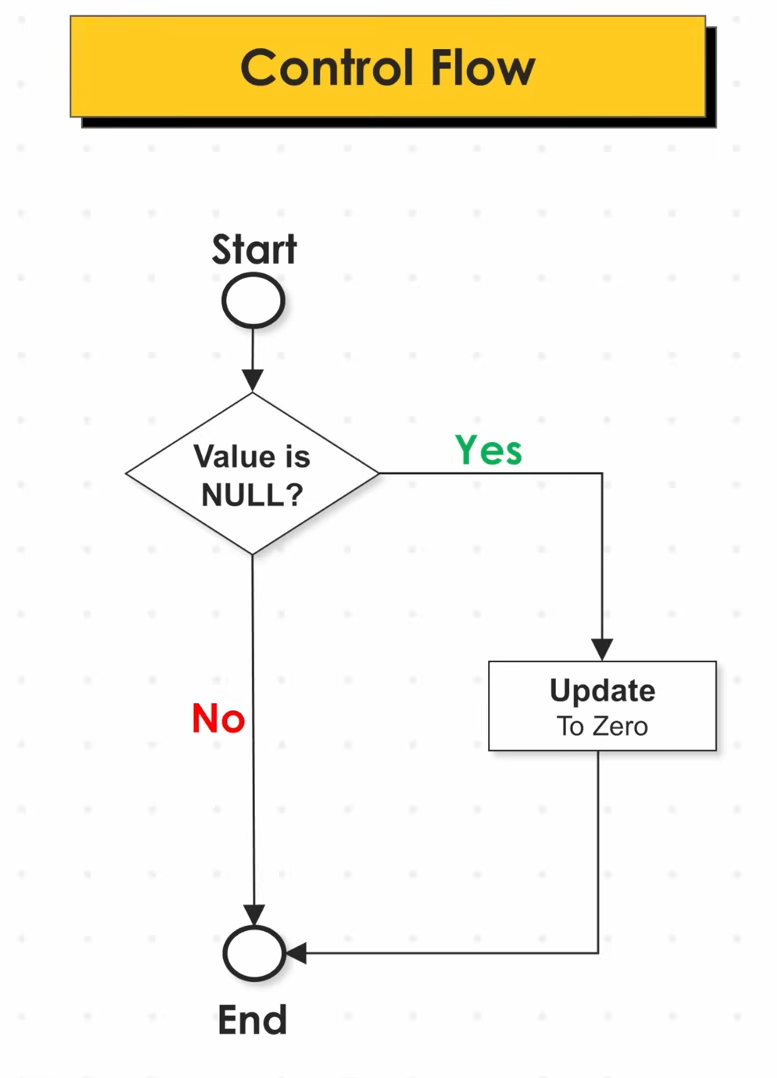

### Stored Procedure Error Handeling TRY-CATCH : 

#### Definition : 

```
TRY CATCH method helps to handle the error if produced in any code and stops other code in the whole query to get crash.
```

#### Syntax : 

```
BEGIN TRY
    -- SQL statements that may cause error
END TRY

BEGIN CATCH
    -- SQL statements to handle the error
END CATCH
```

#### WorkFlow : 

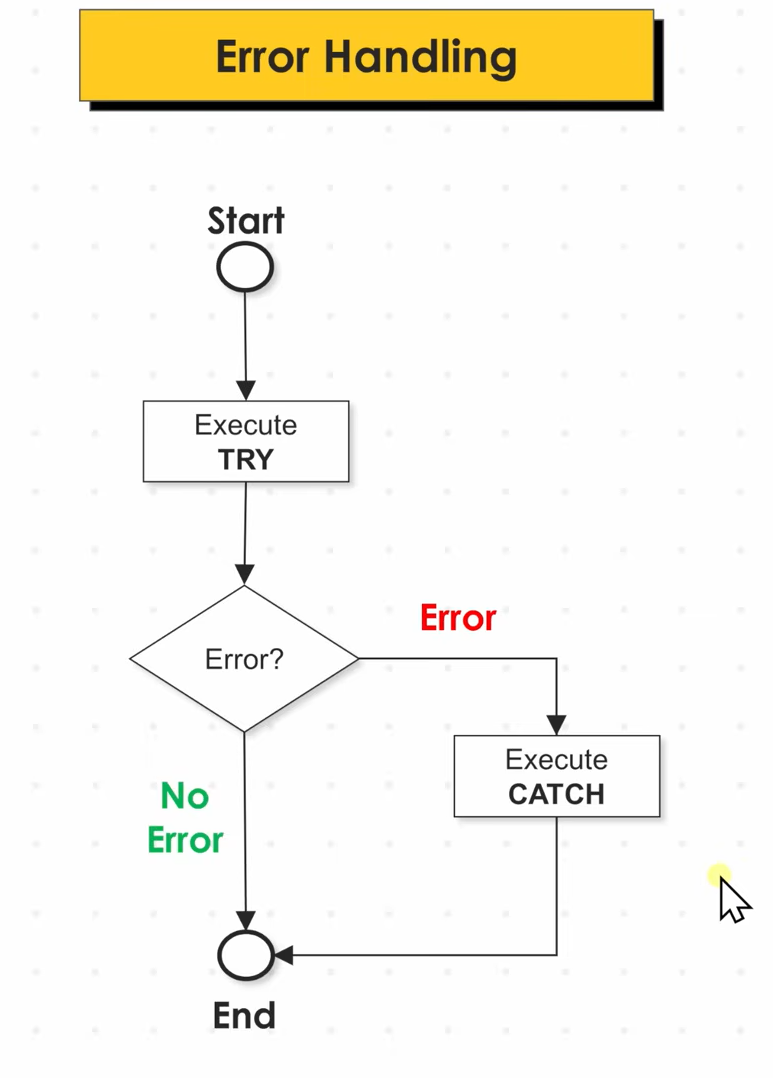

### Challenges : 

##### 1. Find the total number of customers and average score for German customers.

In [234]:
%%sql
select count(customerid) as TotalCustomers,
    round(avg(coalesce(score, 0))) as AVGScore
from customers
where country = 'Germany';

Running query in 'mysql+pymysql://'

1 rows affected.

TotalCustomers,AVGScore
2,425


##### 2. Now create stored procedure for the same above.

In [10]:
%%sql
create procedure GR_Customers() 
BEGIN
select count(customerid) as TotalCustomers,
    round(avg(coalesce(score, 0))) as AVGScore
from customers
where country = 'Germany';
END;

Running query in 'mysql+pymysql://'

++
||
++
++

##### 3. Now fetch the german records using stored procedure execution.

In [11]:
%%sql
call GR_Customers;

Running query in 'mysql+pymysql://'

1 rows affected.

TotalCustomers,AVGScore
2,425


##### ```NOTE : Now its the repeatative code again and again so now create a single code using country as PARAMETER```

##### Single Parameter : 4. Write a parameterised query for orders where the country will be parameter.

In [49]:
%%sql
DROP PROCEDURE IF EXISTS PCBC;
CREATE PROCEDURE PCBC (INOUT CNTRY VARCHAR(50)) 
BEGIN
    select country, count(customerid) as TotalCustomers,
        round(avg(coalesce(score, 0))) as AvgScore
    from customers
    where country = BINARY CNTRY
    group by country;
END;

Running query in 'mysql+pymysql://'

++
||
++
++

In [50]:
%%sql
SET @CNTRY = 'Germany';
CALL PCBC(@CNTRY);

Running query in 'mysql+pymysql://'

1 rows affected.

country,TotalCustomers,AvgScore
Germany,2,425


##### Multiple Parameter : 5. Write a stored procedure query where pass two parameter as sales and country

In [97]:
%%sql
DROP PROCEDURE IF EXISTS SPFDO;
create procedure SPFDO (
    INOUT SaleP INT,
    INOUT StatusP varchar(50)
) 
BEGIN
    select *
    from orders
    where sales > BINARY SaleP
        and orderstatus = BINARY StatusP;
END;

Running query in 'mysql+pymysql://'

++
||
++
++

In [99]:
%%sql
set @SaleP = 21;
set @StatusP = 'Shipped';
CALL SPFDO(@SaleP, @StatusP);

Running query in 'mysql+pymysql://'

3 rows affected.

orderid,productid,customerid,salespersonid,orderdate,shipdate,orderstatus,shipaddress,billaddress,quantity,sales,creationtime
4,105,1,3,2025-01-20,2025-01-25,Shipped,5724 Victory Lane,,2,60,2025-01-20 05:50:33
8,101,4,3,2025-02-18,2025-02-27,Shipped,2947 Vine Lane,4311 Clay Rd,3,90,2025-02-18 10:45:22
10,102,3,5,2025-03-15,2025-03-20,Shipped,None,None,0,60,2025-03-16 23:25:15


##### Multiple with Defaut Parameter  : 6. Write a stored procedure query where pass two parameter as sales and country with default value in code

In [142]:
%%sql
DROP PROCEDURE IF EXISTS MDP;
CREATE PROCEDURE MDP(
                    INOUT SalesP INT,
                    INOUT StatusP varchar(50)
                    )
BEGIN
-- DECLARING DEFAULTS
DECLARE SalesD INT DEFAULT 20;
DECLARE StatusD Varchar(50) DEFAULT 'Delivered';

-- SETTING DEFAULT IF PARAMETER IS NULL
IF SalesP IS NULL THEN
SET SalesP = SalesD;
END IF;

IF StatusP IS NULL THEN
SET StatusP = StatusD;
END IF;

select * from orders where sales > BINARY SalesP and orderstatus = BINARY StatusP;
END

Running query in 'mysql+pymysql://'

++
||
++
++

In [175]:
%%sql
set @SalesP = NULL;
set @StatusP = 'Delivered';
CALL MDP(@SalesP, @StatusP);


Running query in 'mysql+pymysql://'

3 rows affected.

orderid,productid,customerid,salespersonid,orderdate,shipdate,orderstatus,shipaddress,billaddress,quantity,sales,creationtime
5,104,2,5,2025-02-01,2025-02-05,Delivered,None,None,1,25,2025-02-01 14:02:41
6,104,3,5,2025-02-05,2025-02-10,Delivered,1792 Belmont Rd.,None,2,50,2025-02-06 15:34:57
7,102,1,1,2025-02-15,2025-02-27,Delivered,136 Balboa Court,,2,30,2025-02-16 06:22:01


##### Multiple Statements : 7. Create a multi statements stored procedure.

###### Write a query to finad out Monthly Sales and Total orders

In [216]:
%%sql
select monthname(orderdate) as Months,
    count(orderid) as TotalOrders,
    sum(coalesce(sales, 0)) as TotalSales
from orders
group by month(orderdate), monthname(orderdate)
order by month(orderdate);

Running query in 'mysql+pymysql://'

3 rows affected.

Months,TotalOrders,TotalSales
January,4,105
February,4,195
March,2,80


###### Write a query to find out total orders and running orders and total sales and running sales by each customers by each months

In [217]:
%%sql
select concat_ws(' ', c.firstname, c.lastname) as Customer,
    c.country,
    count(o.orderid) as TotalOrders,
    sum(count(o.orderid)) over(
        partition by c.customerid
        order by month(o.orderdate)
    ) as RunningOrders,
    monthname(o.orderdate) as Months,
    sum(coalesce(o.sales, 0)) as TotalSales,
    sum(sum(o.sales)) over(
        partition by c.customerid
        order by month(o.orderdate)
    ) as RunningSales
from orders as o
    left join customers as c on o.customerid = c.customerid
group by c.customerid,
    concat_ws(' ', c.firstname, c.lastname),
    c.country,
    month(o.orderdate),
    monthname(o.orderdate)
order by c.customerid,
    Month(o.orderdate);

Running query in 'mysql+pymysql://'

9 rows affected.

Customer,country,TotalOrders,RunningOrders,Months,TotalSales,RunningSales
Jossef Goldberg,Germany,2,2,January,80,80
Jossef Goldberg,Germany,1,3,February,30,110
Kevin Brown,USA,1,1,January,10,10
Kevin Brown,USA,1,2,February,25,35
Kevin Brown,USA,1,3,March,20,55
Mary,USA,1,1,January,15,15
Mary,USA,1,2,February,50,65
Mary,USA,1,3,March,60,125
Mark Schwarz,Germany,1,1,February,90,90


###### Now create a stored procedure that hold both query above

In [224]:
%%sql
DROP PROCEDURE IF EXISTS MQSP;

Create procedure MQSP()
BEGIN
    select monthname(orderdate) as Months,
        count(orderid) as TotalOrders,
        sum(coalesce(sales, 0)) as TotalSales
    from orders
    group by month(orderdate), monthname(orderdate)
    order by month(orderdate);

    select concat_ws(' ', c.firstname, c.lastname) as Customer,
    c.country,
    count(o.orderid) as TotalOrders,
    sum(count(o.orderid)) over(
        partition by c.customerid
        order by month(o.orderdate)
    ) as RunningOrders,
    monthname(o.orderdate) as Months,
    sum(coalesce(o.sales, 0)) as TotalSales,
    sum(sum(o.sales)) over(
        partition by c.customerid
        order by month(o.orderdate)
    ) as RunningSales
    from orders as o
        left join customers as c on o.customerid = c.customerid
    group by c.customerid,
        concat_ws(' ', c.firstname, c.lastname),
        c.country,
        month(o.orderdate),
        monthname(o.orderdate)
    order by c.customerid,
        Month(o.orderdate);
    
END;

Running query in 'mysql+pymysql://'

++
||
++
++

In [223]:
%%sql
call MQSP;

Running query in 'mysql+pymysql://'

3 rows affected.

Months,TotalOrders,TotalSales
January,4,105
February,4,195
March,2,80


##### SP Variables : 8. Create variables in stored procedure and make the output like :
```
1. Total Customers from COUNTRY = TotalCustomers
2. Average Score from COUNTRY = AVERAGESCORE
```

In [52]:
%%sql
DROP PROCEDURE IF EXISTS MVSP;

CREATE PROCEDURE MVSP(IN CountryP Varchar(50))
BEGIN

DECLARE TotalCustomers INT;
DECLARE AvgScore DECIMAL(10,1);

    select 
        count(customerid),
        round(AVG(COALESCE(score, 0)), 1)
        INTO TotalCustomers, AvgScore
    from customers
    where country = BINARY CountryP;

    select concat_ws(' ', 'Total Sales from', CountryP, ' = ', TotalCustomers) as ' '
    UNION ALL
    select concat_ws(' ', 'Average Scores from', CountryP, ' = ', AvgScore);

END;

Running query in 'mysql+pymysql://'

++
||
++
++

In [53]:
%%sql
call MVSP('Germany');

Running query in 'mysql+pymysql://'

2 rows affected.

""
Total Sales from Germany = 2
Average Scores from Germany = 425.0


In [54]:
%%sql
call MVSP('USA');

Running query in 'mysql+pymysql://'

2 rows affected.

""
Total Sales from USA = 3
Average Scores from USA = 550.0


##### SP Variables and IF ELSE: 9. Create variables in stored procedure and make the output like :
```
First Prepare the data and if any null in table then replace with 0
Then Calculate below
1. Total Customers from COUNTRY = TotalCustomers
2. Average Score from COUNTRY = AVERAGESCORE
```

In [115]:
%%sql
drop procedure if exists IESP;
create procedure IESP(IN CountryP Varchar(50)) 
BEGIN
-- Generating Report
    DECLARE TotalCustomers INT;
    DECLARE AverageScore DECIMAL(10, 1);

/* -- COMMENTED FROM HERE TO --------------
    IF (EXISTS (select 1 as '' from customers where score IS NULL AND country = BINARY CountryP))
    THEN
        SELECT ('Updating NULL to 0 ....') as '';
        UPDATE customers
        set score = 0
        where score IS NULL AND country = BINARY CountryP;

    ELSE
        SELECT ('No NULL found ....') as '';
    END IF;
*/ ------------ HERE 

    select 
        count(customerid),
        avg(coalesce(score, 0)) 
        into TotalCustomers, AverageScore
    from customers
    where country = BINARY CountryP;

-- Printing Report
    select concat_ws(' ', 'Total Customers from', CountryP, ' = ', TotalCustomers) as ''
    UNION ALL
    select concat_ws(' ', 'Average Score from', CountryP, ' = ', AverageScore);

END;

Running query in 'mysql+pymysql://'

++
||
++
++

In [114]:
%%sql
call IESP('USA');

Running query in 'mysql+pymysql://'

2 rows affected.

""
Total Customers from USA = 3
Average Score from USA = 550.0


##### 10. TRY CATCH in Stored Procedure : 

In [148]:
%%sql
drop procedure if exists TCSP;
create procedure TCSP(IN CountryP Varchar(50)) 
BEGIN
    DECLARE TotalCustomers INT;
    DECLARE AverageScore DECIMAL(10, 1);


-- ERROR HANDELER 
    DECLARE EXIT HANDLER FOR SQLEXCEPTION
    BEGIN
    GET DIAGNOSTICS CONDITION 1
            @sys_err_no = MYSQL_ERRNO, 
            @sys_msg    = MESSAGE_TEXT;
    END;

    

-- Generating Report
    select 
        count(customerid),
        avg(coalesce(score, 0)),
        1/0 
        into TotalCustomers, AverageScore
    from customers
    where country = BINARY CountryP;

-- Printing Report
    select concat_ws(' ', 'Total Customers from', CountryP, ' = ', TotalCustomers) as ''
    UNION ALL
    select concat_ws(' ', 'Average Score from', CountryP, ' = ', AverageScore);

END;

Running query in 'mysql+pymysql://'

++
||
++
++

In [149]:
%%sql
call TCSP('USA')

Running query in 'mysql+pymysql://'

++
||
++
++

## SUMMARY : 

# 6. TRIGGERS

## Intro : 

## Types : 

## USECASES : 

## SUMMARY : 

# Extra :

In [68]:
%%sql
use salesdb;

Running query in 'mysql+pymysql://'

++
||
++
++

In [1]:
%%sql
show databases;

Running query in 'mysql+pymysql://'

7 rows affected.

Database
MyDatabase
defaultdb
information_schema
mysql
performance_schema
salesdb
sys
